### Метод дихотомии

![slide-42 (1).jpg](<attachment:slide-42 (1).jpg>)

![function_plot (1).png](<attachment:function_plot (1).png>)

In [3]:
def dichotomy_method(func, a, b, eps=1e-6, delta=1e-6, max_iter=1000):

    for i in range(max_iter):
        x1 = (a + b)/2 - delta
        x2 = (a + b)/2 + delta
        
        f1 = func(x1)
        f2 = func(x2)
        
        if f1 < f2:
            b = x2
        else:
            a = x1
        
        if (b - a)/2 < eps:
            print(f"Сошлось за {i+1} итераций")
            return (a + b)/2
    
    print("Достигнуто максимальное число итераций")
    return (a + b)/2

# --- ввод от пользователя ---
import math

func_str = input("Введите функцию f(x), например, (x**4 - 18*x**2 + 6)**2: ")
a = float(input("Введите левую границу интервала a: "))
b = float(input("Введите правую границу интервала b: "))

func = eval(f"lambda x: {func_str}")

root = dichotomy_method(func, a, b)
print(f"Приближённый корень/минимум: {root:.6f}")
print(f"f(root) ≈ {func(root):.6e}")


Достигнуто максимальное число итераций
Приближённый корень/минимум: -4.202411
f(root) ≈ 7.712894e-21


### Метод Ньютона

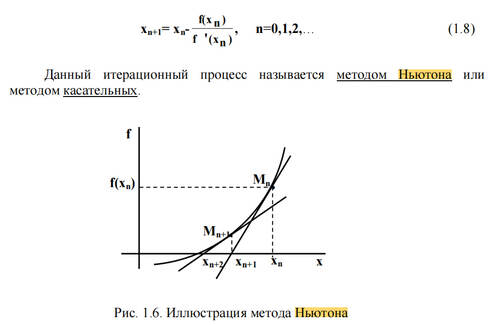

In [6]:
import sympy as sp

def newton_method(func_str, x0, eps=1e-6, max_iter=100):

    x = sp.symbols('x')
    f_sym = sp.sympify(func_str)
    
    f_prime = sp.lambdify(x, sp.diff(f_sym, x), 'math')        # f'(x)
    f_double_prime = sp.lambdify(x, sp.diff(f_sym, x, 2), 'math')  # f''(x)
    
    x_n = x0
    for i in range(max_iter):
        f1 = f_prime(x_n)
        f2 = f_double_prime(x_n)
        
        if f2 == 0:
            print("Вторая производная равна нулю, метод не применим")
            return x_n
        
        x_next = x_n - f1 / f2
        
        if abs(x_next - x_n) < eps:
            print(f"Сошлось за {i+1} итераций")
            return x_next
        
        x_n = x_next
    
    print("Достигнуто максимальное число итераций")
    return x_n


func_str = input("Введите функцию f(x), например, (x**4 - 18*x**2 + 6)**2: ")
x0 = float(input("Введите начальное приближение x0: "))

root = newton_method(func_str, x0)
print(f"Приближённый минимум/корень: {root:.6f}")


ModuleNotFoundError: No module named 'sympy'